In [1]:

import os
import re
import pandas as pd
import numpy as np
import optuna
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, accuracy_score,classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from tqdm import tqdm
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings("ignore")



In [2]:
from huggingface_hub import notebook_login
notebook_login()

In [2]:
# for code run locally
# login to hugging face

splits = {
    'train': 'task_a/task_a_training_set_1.parquet', 
    'validation': 'task_a/task_a_validation_set.parquet', 
    'test': 'task_a/task_a_test_set_sample.parquet'
}

base_path = "hf://datasets/DaniilOr/SemEval-2026-Task13/"

# Load each split into Pandas
train_data = pd.read_parquet(base_path + splits["train"])
val_data = pd.read_parquet(base_path + splits["validation"])
test_data = pd.read_parquet(base_path + splits["test"])

In [ ]:
# # run code on kaggle

# train_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_training_set_1.parquet"
# val_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_validation_set.parquet"
# test_path = "/kaggle/input/semeval-2026-task13/SemEval-2026-Task13/task_a/task_a_test_set_sample.parquet"


# # load train,test & validation data
# train_data = pd.read_parquet(train_path)
# val_data = pd.read_parquet(val_path)
# test_data = pd.read_parquet(test_path)

In [4]:
train_data.head()

,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python
2,python\ndef min_cards_to_flip(s):\n vowels ...,Qwen/Qwen2.5-Coder-7B-Instruct,1,Python
3,T = int(input())\nfor t in range(T):\n\tcolor ...,human,0,Python
4,for i in range(int(input())):\n\tinput()\n\ta ...,human,0,Python


In [5]:


# Basic cleaning
# ====================================================
#  Extra features 
# ====================================================

camel_case_pattern = r'\b[a-z]+(?:[A-Z][a-z0-9]+)+\b'
snake_case_pattern = r'\b[a-z]+(?:_[a-z0-9]+)+\b'

def count_camel(text):
    return len(re.findall(camel_case_pattern, text))

def count_snake(text):
    return len(re.findall(snake_case_pattern, text))


# training dataset

train_data['code'] = train_data['code'].astype(str)

train_data['camel_count'] = train_data['code'].apply(count_camel)
train_data['snake_count'] = train_data['code'].apply(count_snake)

train_data['total_idents'] = train_data['camel_count'] + train_data['snake_count']
train_data['camel_ratio'] = train_data['camel_count'] / (train_data['total_idents'] + 1e-5)
train_data['snake_ratio'] = train_data['snake_count'] / (train_data['total_idents'] + 1e-5)


# Code Features Extraction 
train_data["code_length"] = train_data["code"].str.len()
train_data['num_comments'] = train_data['code'].str.count("#|//")
train_data['num_tabs'] = train_data['code'].str.count("\t")
train_data['num_spaces'] = train_data['code'].str.count("    ")

train_data["num_lines"] = train_data["code"].apply(lambda x: x.count("\n") + 1)
train_data["num_defs"] = train_data["code"].str.count(r"\bdef\b")
train_data["num_for"] = train_data["code"].str.count(r"\bfor\b")
train_data["num_if"] = train_data["code"].str.count(r"\bif\b")
train_data["num_import"] = train_data["code"].str.count(r"\bimport\b")


In [6]:
# test dataset 

test_data['code'] = test_data['code'].astype(str)

test_data['camel_count'] = test_data['code'].apply(count_camel)
test_data['snake_count'] = test_data['code'].apply(count_snake)
test_data['total_idents'] = test_data['camel_count'] + test_data['snake_count']
test_data['camel_ratio'] = test_data['camel_count'] / (test_data['total_idents'] + 1e-5)
test_data['snake_ratio'] = test_data['snake_count'] / (test_data['total_idents'] + 1e-5)

# Code Features Extraction 
test_data["code_length"] = test_data["code"].str.len()
test_data['num_comments'] = test_data['code'].str.count("#|//")
test_data['num_tabs'] = test_data['code'].str.count("\t")
test_data['num_spaces'] = test_data['code'].str.count("    ")

test_data["num_lines"] = test_data["code"].apply(lambda x: x.count("\n") + 1)
test_data["num_defs"] = test_data["code"].str.count(r"\bdef\b")
test_data["num_for"] = test_data["code"].str.count(r"\bfor\b")
test_data["num_if"] = test_data["code"].str.count(r"\bif\b")
test_data["num_import"] = test_data["code"].str.count(r"\bimport\b")

In [7]:
# ====================================================
# Train-test split
# ====================================================

X_train_text, y_train = train_data["code"], train_data["label"]
X_test_text, y_test = test_data["code"], test_data["label"]
X_val_text, y_val = val_data["code"], val_data["label"]


## Hyperparameter Tuning Optuna Objective Function

In [ ]:

# ------------------------------------------------------
# Optuna Objective Function
# ------------------------------------------------------
def objective(trial):

    # TF-IDF hyperparameters
    max_features = trial.suggest_categorical("max_features", [10000, 20000, 30000])
    ngram_range = trial.suggest_categorical("ngram_range", [ ])
    min_df = trial.suggest_float("min_df", 1e-5, 0.01, log=True)

    # Logistic Regression hyperparameters
    C = trial.suggest_float("C", 1e-3, 10, log=True)
    solver = trial.suggest_categorical("solver", ["liblinear", "lbfgs"])
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

    # Pipeline definition
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(
            strip_accents="unicode",
            analyzer="word",
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df
        )),
        ("clf", LogisticRegression(
            C=C,
            solver=solver,
            class_weight=class_weight,
            max_iter=5000,
            n_jobs=-1
        ))
    ])

    # Fit model
    pipe.fit(X_train_text, y_train)

    # Predict & compute F1 score
    preds = pipe.predict(X_test_text)
    score = f1_score(y_test, preds, average="macro")

    return score


# ------------------------------------------------------
# Run Optuna Study
# ------------------------------------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)  # increase n_trials for better results

# Best hyperparameters
print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

# best_params = {'max_features': 30000, 'ngram_range': (1, 1), 'min_df': 0.0015430189491796615, 'C': 8.853443301355558, 'solver': 'liblinear', 'class_weight': 'balanced'}

In [4]:
best_params = {'max_features': 30000, 'ngram_range': (1, 1), 'min_df': 0.0015430189491796615, 'C': 8.853443301355558, 'solver': 'liblinear', 'class_weight': 'balanced'}

In [8]:
tfidf = TfidfVectorizer(
        strip_accents="unicode",
        analyzer="word",
        max_features=best_params["max_features"],
        ngram_range=best_params["ngram_range"],
        min_df=best_params["min_df"]
    )


X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)
# validation data
X_val_tfidf  = tfidf.transform(X_val_text)

In [25]:

# ====================================================
#  Metadata features
# ====================================================

meta_features = [
    # 'language',
    'camel_count',
    'snake_count',
    'camel_ratio',
    'snake_ratio',
    "code_length",
    "num_comments",
    "num_tabs",
    "num_spaces",
    "num_lines",
    "num_defs",
    "num_for",
    "num_if",
    "num_import"   
]

X_train_meta = train_data[meta_features].values
X_test_meta = test_data[meta_features].values


# Combine sparse and dense features
from scipy.sparse import hstack

X_train_meta_tfidf_data = hstack([X_train_tfidf, X_train_meta])
X_test_meta_tfidf_data  = hstack([X_test_tfidf, X_test_meta])

In [10]:

# ====================================================
#  Define Models
# ====================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Multinomial NB": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

# Optional (if installed)
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        eval_metric='logloss',
        tree_method='hist'
    )
except:
    pass

try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier()
except:
    pass

# ====================================================
# Train and Evaluate All Models
# ====================================================

results = []

for name, model in models.items():
    print("="*60)
    print(f"Training {name}...")
    
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(classification_report(y_test, pred))

    results.append([name, acc, f1])

# Results summary
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df = results_df.sort_values("F1 Score", ascending=False)

print("\n\n==== FINAL RESULTS ====")
print(results_df)



Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.90      0.32      0.48       777
           1       0.27      0.87      0.41       223

    accuracy                           0.45      1000
   macro avg       0.58      0.60      0.44      1000
weighted avg       0.76      0.45      0.46      1000

Training Multinomial NB...
              precision    recall  f1-score   support

           0       0.86      0.20      0.32       777
           1       0.24      0.89      0.38       223

    accuracy                           0.35      1000
   macro avg       0.55      0.54      0.35      1000
weighted avg       0.72      0.35      0.33      1000

Training Linear SVM...
              precision    recall  f1-score   support

           0       0.90      0.36      0.51       777
           1       0.28      0.86      0.42       223

    accuracy                           0.47      1000
   macro avg       0.59      0.61      0.46   

<!-- Train The Model on Combine  Metadata features and tfidf vectors --> 

In [12]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Multinomial NB": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    # "Decision Tree": DecisionTreeClassifier(),
    # "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

# Optional (if installed)
try:
    from xgboost import XGBClassifier
    models["XGBoost"] = XGBClassifier(
        eval_metric='logloss',
        tree_method='hist'
    )
except:
    pass



results = []

for name, model in models.items():
    print("="*60)
    print(f"Training {name}...")
    
    model.fit(X_train_meta_tfidf_data, y_train)
    pred = model.predict(X_test_meta_tfidf_data)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(classification_report(y_test, pred))

    results.append([name, acc, f1])

# Results summary
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df = results_df.sort_values("F1 Score", ascending=False)

print("\n\n==== FINAL RESULTS ====")
print(results_df)



Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.86      0.33      0.48       777
           1       0.26      0.81      0.39       223

    accuracy                           0.44      1000
   macro avg       0.56      0.57      0.43      1000
weighted avg       0.72      0.44      0.46      1000

Training Multinomial NB...
              precision    recall  f1-score   support

           0       0.93      0.27      0.42       777
           1       0.27      0.93      0.42       223

    accuracy                           0.42      1000
   macro avg       0.60      0.60      0.42      1000
weighted avg       0.78      0.42      0.42      1000

Training Linear SVM...
              precision    recall  f1-score   support

           0       0.86      0.32      0.47       777
           1       0.26      0.82      0.39       223

    accuracy                           0.43      1000
   macro avg       0.56      0.57      0.43   

##  XGBClassifier

In [24]:
#
def dedupe(df):
    return df.drop_duplicates(subset=["code"]).reset_index(drop=True)
train = dedupe(train_data)
val = dedupe(val_data)
test = dedupe(test_data)

print(len(train), len(val), len(test))

500000 100000 1000


In [27]:
train.head(2)

,code,generator,label,language
0,"(a, b, c, d) = [int(x) for x in input().split(...",human,0,Python
1,valid version for the language; all others can...,Qwen/Qwen2.5-Coder-1.5B,1,Python


In [30]:
 
def normalize(code):
    return code.replace("\t", " ").replace("\r", "").strip()

train["code"] = train["code"].apply(normalize)
val["code"] = val["code"].apply(normalize)
test["code"] = test["code"].apply(normalize)


tfidf = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3,6),
    max_features=20000,
    min_df=2  
)

tfidf_train = tfidf.fit_transform(train["code"])
tfidf_val   = tfidf.transform(val["code"])
tfidf_test  = tfidf.transform(test["code"])

print("TF-IDF shape:", tfidf_train.shape)

TF-IDF shape: (500000, 20000)


In [31]:
X_train = tfidf_train
X_val   = tfidf_val
X_test  = tfidf_test

y_train = train["label"]
y_val   = val["label"]
y_test  = test["label"]

print(X_train.shape)


(500000, 20000)


In [32]:
from xgboost import XGBClassifier
clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.5,
    max_bin=128,
    tree_method="hist",
    eval_metric="logloss",
    early_stopping_rounds=50,
    verbosity=1
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)




[0]	validation_0-logloss:0.67553
[1]	validation_0-logloss:0.65927
[2]	validation_0-logloss:0.64439
[3]	validation_0-logloss:0.63035
[4]	validation_0-logloss:0.61698
[5]	validation_0-logloss:0.60441
[6]	validation_0-logloss:0.59165
[7]	validation_0-logloss:0.58011
[8]	validation_0-logloss:0.56888
[9]	validation_0-logloss:0.55799
[10]	validation_0-logloss:0.54706
[11]	validation_0-logloss:0.53713
[12]	validation_0-logloss:0.52765
[13]	validation_0-logloss:0.51908
[14]	validation_0-logloss:0.50976
[15]	validation_0-logloss:0.50169
[16]	validation_0-logloss:0.49355
[17]	validation_0-logloss:0.48585
[18]	validation_0-logloss:0.47802
[19]	validation_0-logloss:0.47093
[20]	validation_0-logloss:0.46410
[21]	validation_0-logloss:0.45683
[22]	validation_0-logloss:0.45066
[23]	validation_0-logloss:0.44473
[24]	validation_0-logloss:0.43886
[25]	validation_0-logloss:0.43266
[26]	validation_0-logloss:0.42714
[27]	validation_0-logloss:0.42142
[28]	validation_0-logloss:0.41612
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,50
,enable_categorical,False
,eval_metric,'logloss'


In [36]:
# Evaluation of the model on the test dataset
pred = clf.predict(X_val)
print(classification_report(y_val, pred, digits=4))

              precision    recall  f1-score   support

           0     0.9199    0.9515    0.9354     47695
           1     0.9544    0.9244    0.9391     52305

    accuracy                         0.9373    100000
   macro avg     0.9371    0.9380    0.9373    100000
weighted avg     0.9379    0.9373    0.9374    100000



In [ ]:

# ====================================================
#  Define Models
# ====================================================

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Multinomial NB": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    # "Decision Tree": DecisionTreeClassifier(), (takes too long to train)
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}


try:
    from lightgbm import LGBMClassifier
    models["LightGBM"] = LGBMClassifier()
except:
    pass

# ====================================================
# Train and Evaluate All Models
# ====================================================

results = []

for name, model in models.items():
    print("="*60)
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    print(classification_report(y_test, pred))
    
    # Evaluation of the model on the validation dataset 
    print("\nValidation Set Evaluation:")
    pred = model.predict(X_val)
    print(classification_report(y_val, pred, digits=4))
    

    results.append([name, acc, f1])

# Results summary
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score"])
results_df = results_df.sort_values("F1 Score", ascending=False)

print("\n\n==== FINAL RESULTS ====")
print(results_df)



Training Logistic Regression...
              precision    recall  f1-score   support

           0       0.91      0.15      0.26       777
           1       0.24      0.95      0.39       223

    accuracy                           0.33      1000
   macro avg       0.57      0.55      0.32      1000
weighted avg       0.76      0.33      0.29      1000


Validation Set Evaluation:
              precision    recall  f1-score   support

           0     0.9305    0.9532    0.9417     47695
           1     0.9564    0.9351    0.9456     52305

    accuracy                         0.9437    100000
   macro avg     0.9434    0.9442    0.9437    100000
weighted avg     0.9440    0.9437    0.9438    100000

Training Multinomial NB...
              precision    recall  f1-score   support

           0       0.87      0.08      0.15       777
           1       0.23      0.96      0.37       223

    accuracy                           0.28      1000
   macro avg       0.55      0.52      0.

### Best Model From Experiments Is SVM with TF-IDF

In [14]:
best_params

{'max_features': 30000,
 'ngram_range': (1, 1),
 'min_df': 0.0015430189491796615,
 'C': 8.853443301355558,
 'solver': 'liblinear',
 'class_weight': 'balanced'}

In [202]:
logisticRegressionclf =  LogisticRegression(
            C=best_params['C'],
            solver=best_params['solver'],
            class_weight=best_params['class_weight'],
            max_iter=5000,
            n_jobs=-1
        )

print("="*60)    
logisticRegressionclf.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,8.853443301355558
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [204]:

def custom_predict(model, X_data, threshold):
    """
    Generates class predictions based on a custom threshold.
    """
    probs = model.predict_proba(X_data)
    # Return 1 if the positive class probability is >= threshold, else 0
    return (probs[:, 1] >= threshold).astype(int)

# Usage:
pred = custom_predict(logisticRegressionclf, X_test_tfidf, threshold=0.6)


acc = accuracy_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(classification_report(y_test, pred))
print("="*60)
print(f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

              precision    recall  f1-score   support

           0       0.90      0.41      0.57       777
           1       0.29      0.83      0.43       223

    accuracy                           0.51      1000
   macro avg       0.59      0.62      0.50      1000
weighted avg       0.76      0.51      0.54      1000

Accuracy: 0.5080, F1 Score: 0.4306


## Error Analysis

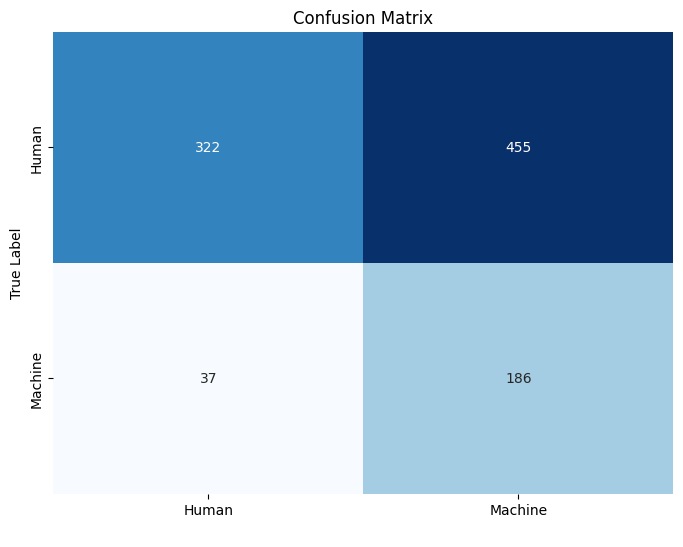

In [205]:
#  i want to show it using giraphical representation  give name to lable  "human": 0, "machine": 1
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Human', 'Machine'],
            yticklabels=['Human', 'Machine'])   
plt.xlabel(' ')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
# Save figure as PDF
plt.savefig("plots/confusion_matrix_svm_human_vs_machine.pdf", bbox_inches="tight")
plt.show()


641

In [147]:
test_data["label"].value_counts()

label
0    777
1    223
Name: count, dtype: int64

In [207]:

report = classification_report(y_test, pred, output_dict=True)
pd.DataFrame(report)

,0,1,accuracy,macro avg,weighted avg
precision,0.896936,0.290172,0.508,0.593554,0.761627
recall,0.414414,0.834081,0.508,0.624248,0.508000
f1-score,0.566901,0.430556,0.508,0.498728,0.536496
support,777.000000,223.000000,0.508,1000.000000,1000.000000


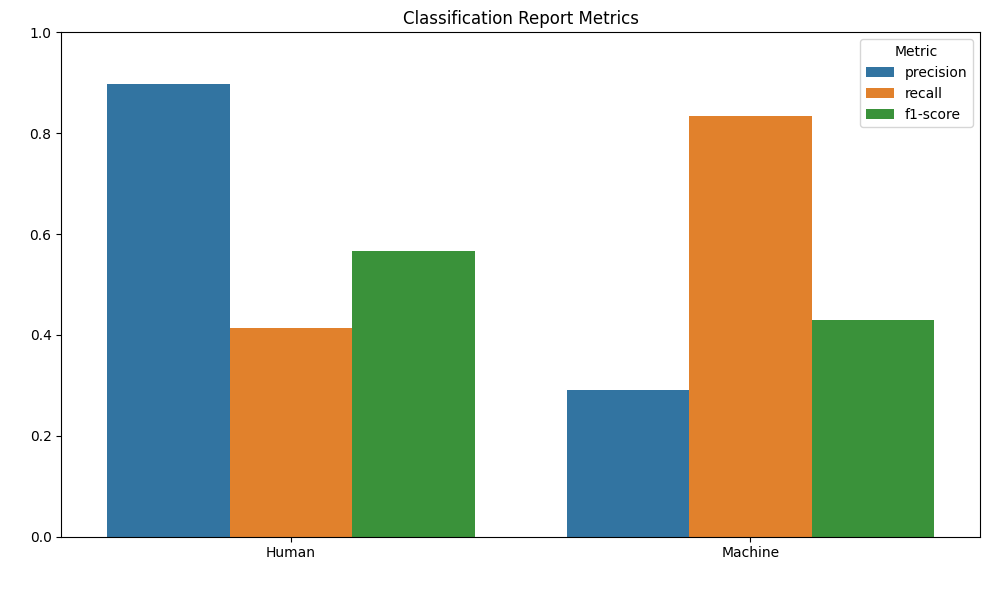

In [277]:
# Generate classification report
report = classification_report(y_test, pred, output_dict=True)
df = pd.DataFrame(report).transpose()

# Keep only class rows (drop accuracy, macro avg, weighted avg)
metrics = df.iloc[:-3][['precision', 'recall', 'f1-score']]

# Rename classes
metrics.index = metrics.index.map({
    '0': 'Human',
    '1': 'Machine'
})

# Convert to long format for seaborn
metrics_long = metrics.reset_index().melt(
    id_vars='index',
    var_name='Metric',
    value_name='Score'
)

# Plot with seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    data=metrics_long,
    x='index',
    y='Score',
    hue='Metric'
)

plt.title("Classification Report Metrics")
plt.xlabel(" ")
plt.ylabel(" ")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("plots/classification_report_metrics.pdf", bbox_inches="tight")
plt.show()

### Interpretation

Class 0 interpretation

+ When model predicts 0 → usually correct (high precision)

+ But it rarely predicts 0 → so it misses many real 0s (low recall)

Class 1 interpretation

+ Model predicts 1 a LOT → catches most class 1’s (high recall)

+ But many of the "1" predictions are wrong (low precision)

## Wrong Predictions

In [209]:
errors = []
for i in range(len(y_test)):
    if y_test[i] != pred[i]:
        errors.append({
            "text": X_test_text[i],   
            "true": y_test[i],
            "pred": pred[i]
        })

import pandas as pd
errors_df = pd.DataFrame(errors)
errors_df.head(20)

,text,true,pred
0,public Vector To(Vector o)\n {\n ...,0,1
1,func (v *DefaultMessageSyntaxValidator) Valida...,0,1
2,"""""""Module managing testsuite capabilities\n\nC...",0,1
3,/*\n * Copyright 2008-2011 the original author...,0,1
4,import paddle\nimport paddle.fluid as fluid\ni...,0,1
5,protected void checkIsSplitToJobsAllowed(Gridi...,0,1
6,"def _set_filename(self, filename, *, force_ove...",0,1
7,private static void spatialSearch(String searc...,0,1
8,"def scan(self, string):\n w = (constrai...",0,1
9,<?php\ndeclare(strict_types=1);\n\nnamespace L...,0,1


## Look at the Worst Predictions (Highest Probability Errors)

In [210]:
probs = logisticRegressionclf.predict_proba(X_test_tfidf)
confidences = probs.max(axis=1)

wrong_indices = (pred != y_test)

worst_df = pd.DataFrame({
    "text": X_test_text,
    "true": y_test,
    "pred": pred,
    "confidence": confidences
})[wrong_indices]

worst_df = worst_df.sort_values(by="confidence", ascending=False)
worst_df.head(15)


,text,true,pred,confidence
976,/**\n * ======================================...,0,1,1.000000
972,"""""""\nCheck that we can dir() in org.python.cor...",0,1,1.000000
532,public class Callback {\n\t\n\tObject object;\...,0,1,1.000000
55,/*********************************************...,0,1,1.000000
725,public abstract class AbstractCommonAttributeI...,0,1,1.000000
884,/* -*- c-basic-offset: 4 indent-tabs-mode: nil...,0,1,1.000000
627,"def train_model(model, xtrain, ytrain, xtest, ...",0,1,1.000000
352,abstract public class MeasureType<T> {\n\n ...,0,1,1.000000
776,class OverlayContainer extends Component {\n ...,0,1,1.000000
672,"""""""\nrinnaicontrolr -- Python client for the R...",0,1,1.000000


In [211]:
errors_df["length"] = errors_df["text"].apply(len)
errors_df.groupby("true")["length"].describe()


,count,mean,std,min,25%,50%,75%,max
true,,,,,,,,
0,455.0,1594.147253,1791.778894,120.0,551.0,958.0,1847.5,12472.0
1,37.0,1306.135135,1119.289139,77.0,255.0,1023.0,1977.0,4041.0


In [ ]:
from itertools import chain
from datasets import load_dataset
from tqdm import tqdm


def predict_with_svm(
    svm_model,
    vectorizer,
    parquet_path,
    output_path,
    batch_size=512
):
    """
    Streaming inference for SVM when parquet file has:
    ['code', 'generator', 'label', 'language']
    """

    # Stream parquet
    ds = load_dataset(
        "parquet",
        data_files=parquet_path,
        split="train",
        streaming=True
    )

    it = iter(ds)
    first = next(it)

    # Must contain 'code' column
    if not {"ID", "code"}.issubset(first.keys()):
        raise ValueError("Parquet file must contain 'ID' and 'code' columns")

    # Rechain for full iterator
    stream = chain([first], it)

    # Streaming batcher
    def batcher(iterator, bs):
        buf = []
        for ex in iterator:
            buf.append(ex)
            if len(buf) == bs:
                yield buf
                buf = []
        if buf:
            yield buf

    # Write CSV
    with open(output_path, "w") as f:
        f.write("ID,label\n")


        for batch in tqdm(batcher(stream, batch_size), desc="Predicting (SVM)"):
            print(batch)
            codes = [row["code"] for row in batch]
            ids   = [row["ID"] for row in batch]
            

            # Vectorize
            X = vectorizer.transform(codes)

            # Predict
            preds = svm_model.predict_proba(X)
            preds = (probs[:, 1] >= 0.6).astype(int)
            

            # Write predictions with generated IDs
            for ex_id, pred in zip(ids, preds):
                f.write(f"{ex_id},{pred}\n")

    print(f"✅ Predictions saved to {output_path}")


In [273]:
predict_with_svm(
    svm_model=logisticRegressionclf,
    vectorizer=tfidf,
    parquet_path="test.parquet",
    output_path="submission.csv",
    batch_size=1024
)

Predicting (SVM): 1it [00:00,  2.57it/s]

[{'ID': 2005, 'code': "A = map(int, input().split())\na = sorted(A)\nt0 = 0\ntmax = 0\nfor i in range(n):\nlit = a[i] - a[i-1] if i > 0 else 0\ntmax = max(tmax, t0 + lit + M - a[i])\nt0 = max(t0, a[i])\nprint(tmax)/10309.Back to High School Physics/readme.md\nProblem B (Back to High School Physics)\nA car is built such that the center of gravity lies outside the base of the strut, as shown in the figure above.\n\nYou are interested in the center of gravity of this car.\n\nWrite a program that computes the center of gravity of such car. The base of the strut is three times the width. The beam is somewhat longer than the base in one direction and somewhat shorter in the other. The combustion shape of the base may be also modified. \n\nSee the sample case to gain some insight about the geometry.\n\n-----Input-----\n\nThe input file is a positive number on a line by itself.\n\n-----Output-----\n\nOutput has three numbers. The first line is the x coordinate of the center of gravity. The sec

In [10]:
import re
import numpy as np
import pandas as pd
from collections import Counter
from scipy.stats import entropy




def get_indent_levels(lines):
    indents = []
    for line in lines:
        if line.strip():
            indents.append(len(line) - len(line.lstrip()))
    return indents


def token_shape(token):
    if re.fullmatch(r"[A-Z_]+", token):
        return "UPPER_SNAKE"
    if re.fullmatch(r"[a-z]+_[a-z_]+", token):
        return "snake_case"
    if re.fullmatch(r"[a-z]+[A-Z][a-zA-Z]*", token):
        return "camelCase"
    if re.fullmatch(r"[a-zA-Z]+\d+", token):
        return "alpha_num"
    if len(token) > 10:
        return "long_token"
    return "other"






def extract_features(code: str):
    lines = code.split("\n")
    total_lines = len(lines)

    if total_lines == 0:
        return {}

    line_lengths = [len(l) for l in lines if l.strip()]
    blank_lines = [l for l in lines if not l.strip()]

    # --- Comments (language-agnostic heuristic)
    comment_lines = [
        l for l in lines if l.strip().startswith(("#", "//", "/*", "*"))
    ]

    # --- Structural features
    features = {
        "num_lines": total_lines,
        "avg_line_length": np.mean(line_lengths) if line_lengths else 0,
        "std_line_length": np.std(line_lengths) if line_lengths else 0,
        "blank_line_ratio": len(blank_lines) / total_lines,
        "comment_line_ratio": len(comment_lines) / total_lines,
        "code_char_ratio": sum(len(l) for l in lines) / (len(code) + 1e-6),
    }

    # --- Indentation
    indent_levels = get_indent_levels(lines)
    if indent_levels:
        indent_counts = Counter(indent_levels)
        features.update({
            "avg_indent": np.mean(indent_levels),
            "indent_std": np.std(indent_levels),
            "indent_entropy": entropy(list(indent_counts.values()))
        })
    else:
        features.update({
            "avg_indent": 0,
            "indent_std": 0,
            "indent_entropy": 0
        })

    # --- Tabs vs spaces
    tab_count = sum("\t" in l for l in lines)
    space_indent_count = sum(l.startswith(" ") for l in lines)
    features["tabs_vs_spaces_ratio"] = tab_count / (space_indent_count + 1e-6)

    # --- Token shapes
    tokens = re.findall(r"[A-Za-z_][A-Za-z_0-9]*", code)
    shapes = [token_shape(t) for t in tokens]
    shape_counts = Counter(shapes)

    for shape, count in shape_counts.items():
        features[f"shape_{shape}"] = count / (len(tokens) + 1e-6)

    # --- Repetition
    unique_lines = set(lines)
    features["repeated_line_ratio"] = 1 - len(unique_lines) / total_lines

    token_counts = Counter(tokens)
    repeated_tokens = sum(c for c in token_counts.values() if c > 1)
    features["repeated_token_ratio"] = repeated_tokens / (len(tokens) + 1e-6)

    # --- Comment semantics
    comment_lengths = [len(l) for l in comment_lines]
    features["avg_comment_length"] = np.mean(comment_lengths) if comment_lengths else 0

    full_sentence_comments = [
        l for l in comment_lines if l.strip().endswith(".")
    ]
    features["full_sentence_comment_ratio"] = (
        len(full_sentence_comments) / (len(comment_lines) + 1e-6)
    )

    return features





In [12]:

# df is your dataset
feature_df = train_data["code"].apply(extract_features).apply(pd.Series)

# Final training table
X = feature_df.fillna(0)
y = train_data["label"]


In [34]:
logisticRegressionclf =  LogisticRegression(
            C=best_params['C'],
            solver=best_params['solver'],
            class_weight=best_params['class_weight'],
            max_iter=5000,
            n_jobs=-1
        )

print("="*60)    
logisticRegressionclf.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,8.853443301355558
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [35]:
feature_columns = X.columns

In [42]:
# df is your dataset
feature_test_df = test_data["code"].apply(extract_features).apply(pd.Series)

# Final training table
X_test_f = feature_test_df.fillna(0)
y_test_f = test_data["label"]

X_test_f = feature_test_df.reindex(
    columns=feature_columns,
    fill_value=0
)
X_test_f = X_test_f.fillna(0)

In [43]:
X_test_f.columns

Index(['num_lines', 'avg_line_length', 'std_line_length', 'blank_line_ratio',
       'comment_line_ratio', 'code_char_ratio', 'avg_indent', 'indent_std',
       'indent_entropy', 'tabs_vs_spaces_ratio', 'shape_other',
       'repeated_line_ratio', 'repeated_token_ratio', 'avg_comment_length',
       'full_sentence_comment_ratio', 'shape_snake_case', 'shape_UPPER_SNAKE',
       'shape_camelCase', 'shape_long_token', 'shape_alpha_num'],
      dtype='object')

In [44]:

def custom_predict(model, X_data, threshold):
    """
    Generates class predictions based on a custom threshold.
    """
    probs = model.predict_proba(X_data)
    # Return 1 if the positive class probability is >= threshold, else 0
    return (probs[:, 1] >= threshold).astype(int)



In [48]:
pred = custom_predict(logisticRegressionclf, X_test_f, threshold=0.5)


acc = accuracy_score(y_test_f, pred)
f1 = f1_score(y_test_f, pred)

print(classification_report(y_test_f, pred))
print("="*60)
print(f"Accuracy: {acc:.4f}, F1 Score: {f1:.4f}")

              precision    recall  f1-score   support

           0       0.93      0.30      0.45       777
           1       0.27      0.92      0.42       223

    accuracy                           0.43      1000
   macro avg       0.60      0.61      0.43      1000
weighted avg       0.78      0.43      0.44      1000

Accuracy: 0.4350, F1 Score: 0.4205


In [49]:
meta_features =['num_lines', 'avg_line_length', 'std_line_length', 'blank_line_ratio',
       'comment_line_ratio', 'code_char_ratio', 'avg_indent', 'indent_std',
       'indent_entropy', 'tabs_vs_spaces_ratio', 'shape_other',
       'repeated_line_ratio', 'repeated_token_ratio', 'avg_comment_length',
       'full_sentence_comment_ratio', 'shape_snake_case', 'shape_UPPER_SNAKE',
       'shape_camelCase', 'shape_long_token', 'shape_alpha_num']

X_train_meta = X[meta_features].values
X_test_meta = X_test_f[meta_features].values


# Combine sparse and dense features
from scipy.sparse import hstack

X_train_meta_tfidf_data = hstack([X_train_tfidf, X_train_meta])
X_test_meta_tfidf_data  = hstack([X_test_tfidf, X_test_meta])

In [52]:

logisticRegressionclf =  LogisticRegression(
            C=best_params['C'],
            solver=best_params['solver'],
            class_weight=best_params['class_weight'],
            max_iter=5000,
            n_jobs=-1
        )

print("="*60)    

logisticRegressionclf.fit(X_train_meta_tfidf_data, y_train)
pred = logisticRegressionclf.predict(X_test_meta_tfidf_data)
acc = accuracy_score(y_test_f, pred)
f1 = f1_score(y_test_f, pred)
print(classification_report(y_test_f, pred))

              precision    recall  f1-score   support

           0       0.93      0.30      0.45       777
           1       0.27      0.92      0.42       223

    accuracy                           0.43      1000
   macro avg       0.60      0.61      0.43      1000
weighted avg       0.78      0.43      0.44      1000



In [53]:
f1

0.4205128205128205

In [54]:
X

,num_lines,avg_line_length,std_line_length,blank_line_ratio,comment_line_ratio,code_char_ratio,avg_indent,indent_std,indent_entropy,tabs_vs_spaces_ratio,shape_other,repeated_line_ratio,repeated_token_ratio,avg_comment_length,full_sentence_comment_ratio,shape_snake_case,shape_UPPER_SNAKE,shape_camelCase,shape_long_token,shape_alpha_num
0,14.0,17.153846,11.915382,0.071429,0.000000,0.944915,0.923077,0.828487,1.092831,8.000000e+06,1.000000,0.000000,0.904762,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
1,50.0,109.848485,68.314833,0.340000,0.000000,0.986663,0.121212,0.685679,0.135794,0.000000e+00,0.947090,0.320000,0.789683,0.000000,0.0,0.001323,0.029101,0.001323,0.002646,0.018519
2,21.0,42.062500,21.264609,0.238095,0.142857,0.971140,2.750000,2.331845,0.864740,0.000000e+00,0.825000,0.190476,0.700000,44.000000,0.0,0.162500,0.000000,0.000000,0.000000,0.012500
3,17.0,16.312500,5.944732,0.058824,0.000000,0.942238,1.625000,1.316957,1.440235,1.400000e+07,0.787234,0.000000,0.829787,0.000000,0.0,0.000000,0.085106,0.000000,0.000000,0.127660
4,24.0,16.000000,7.089490,0.041667,0.000000,0.941176,1.391304,0.706438,1.001422,2.200000e+07,0.974684,0.041667,0.886076,0.000000,0.0,0.000000,0.025316,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,32.0,33.260870,14.656108,0.281250,0.343750,0.961055,3.478261,2.716609,1.005693,0.000000e+00,0.954545,0.250000,0.727273,43.090909,0.0,0.036364,0.009091,0.000000,0.000000,0.000000
499996,9.0,27.125000,13.605491,0.111111,0.000000,0.964444,0.375000,0.484123,0.661563,3.000000e+06,1.000000,0.222222,0.822222,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
499997,76.0,54.345455,55.875907,0.276316,0.000000,0.975522,0.727273,1.354515,1.002341,2.142857e-01,0.880460,0.368421,0.760920,0.000000,0.0,0.022989,0.011494,0.059770,0.011494,0.013793
499998,11.0,19.571429,5.341405,0.363636,0.090909,0.931973,0.285714,0.699854,0.410116,0.000000e+00,0.923077,0.272727,0.423077,22.000000,0.0,0.000000,0.038462,0.000000,0.000000,0.038462
